# Fractional uplift modelling

> Google LLC의 [Fractional Uplift – End to End Example](https://github.com/google-marketing-solutions/fractional_uplift)를 한국어로 번역 및 정리했습니다.


fractional uplift 모델은 프로모션 비용이 사전에 확정되지 않는 상황에 적합합니다. 

예를 들어, 특정 조건이 있는 쿠폰을 제공하는 경우 쿠폰을 제공하는 시점에는 실제 비용을 알 수 없으며, 비용은 사용자가 어떤 상품을 구매하느냐에 따라 달라집니다.

이러한 상황에서 일반적인 uplift 모델링은 한계가 있습니다. 일반 uplift 모델은 처치로 인한 증분 효과(incrementality)만을 다루고, 비용은 고려하지 않기 때문입니다. 

반면 fractional uplift 모델은 여러 지표를 함께 고려하여 최적화하도록 설계되어 있습니다.

일반적인 uplift 모델은 하나의 지표(예: 전환율 또는 지출 금액)에 대해 조건부 평균 처치 효과(CATE)를 추정합니다.

$$
f_\text{uplift}(X) = \text{CATE}_y(X) = E[y \mid T=1, X] - E[y \mid T=0, X]
$$

fractional uplift 모델은 여러 지표에 대한 CATE 추정치를 결합하여, 다음과 같은 단일 점수를 계산합니다.

$$
f_\text{fractional uplift}(X) =
\begin{cases}
    \dfrac{\text{CATE}_\alpha (X)}
    {\text{CATE}_\beta(X) - \dfrac{\text{CATE}_\gamma (X)}{\delta}},
    & \text{CATE}_\beta(X) > \dfrac{\text{CATE}_\gamma (X)}{\delta} \\
    \infty, & \text{그 외의 경우}
\end{cases}
$$

각 항의 의미는 다음과 같습니다.

- $\alpha$ (Maximize KPI)  
  모델이 최대화하고자 하는 지표입니다.

- $\beta$ (Constraint KPI)  
  제약으로 작용하는 지표로, 가능한 한 낮게 유지하고자 합니다.

- $\gamma$ (Constraint Offset KPI)  
  제약을 상쇄하는 데 사용할 수 있는 지표이며, 선택적으로 사용됩니다.

- $\delta$ (Constraint Offset Scale)  
  constraint offset KPI의 스케일을 조정하는 상수입니다.  
  constraint offset KPI를 사용하지 않는 경우에는 필요하지 않습니다.


In [1]:
%pip install -q fractional-uplift pandas numpy statsmodels tensorflow tensorflow_decision_forests matplotlib

Note: you may need to restart the kernel to use updated packages.


In [134]:
import os

os.environ["OMP_NUM_THREADS"] = "8"
os.environ["TF_NUM_INTRAOP_THREADS"] = "8"
os.environ["TF_NUM_INTEROP_THREADS"] = "2"

In [135]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D

import tensorflow as tf  # tensorflow decision forests가 eager mode로 실행되도록 하기 위해 필요

import warnings
warnings.filterwarnings("ignore")

In [136]:
import tensorflow_decision_forests as tfdf
import fractional_uplift as fr

In [137]:
# tfdf 사용 시 출력되는 Keras 학습 로그 숨김
tfdf.keras.set_training_logs_redirection(False)

## Load the Criteo data

[Criteo dataset](https://ailab.criteo.com/criteo-uplift-prediction-dataset/)은 uplift 모델링을 벤치마킹하기위한 공개된 데이터셋입니다. 여러 incrementality 테스트 결과를 모아 구성되었으며, 각 행은 사용자 한 명을 나타냅니다.

데이터셋에는 다음 정보가 포함되어 있습니다.

- 사용자 특성(feature) 11개
- 처치 여부(treatment)
- 결과 라벨 2개: 방문(visits), 전환(conversions)

이 데이터셋은 전환이나 방문과 같은 단일 KPI를 대상으로 하는 표준 uplift 모델링 문제를 위해 설계되었습니다. 

그러나 이 노트북에서는 사용자에게 프로모션을 제공하는 상황을 가정하여, 보다 현실적인 uplift 모델링 문제를 다룹니다.

이를 위해 다음과 같은 추가 지표를 사용합니다.

- **Spend**: 사용자가 전환했을 때 지출한 금액을 의미하며, 특성(feature)을 기반으로 생성됩니다.

- **Cost:** 또는 쿠폰 비용을 의미합니다. 사용자가 전환한 경우에만 발생하며, 처치된 사용자(T=1)에게서 전환이 발생했을 때에만 비용이 발생하도록 설정합니다.

In [138]:
criteo = fr.example_data.CriteoWithSyntheticCostAndSpend.load()

In [139]:
criteo.train_data.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,treatment_propensity,cost_percentage,spend,cost,sample_weight
44,12.616365,10.059654,8.964588,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0.85,0.000000,0.000000,0.000000,100.0
187,12.616365,10.059654,8.904597,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0.85,0.000000,0.000000,0.000000,100.0
484,22.377238,10.059654,8.214383,4.679882,10.280525,4.115453,-2.411115,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0.85,0.000000,0.000000,0.000000,100.0
528,12.616365,10.059654,8.350682,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,16.226044,5.300375,-0.168679,1,0,0.85,0.000000,0.000000,0.000000,100.0
1108,14.617627,10.059654,8.489929,3.907662,13.253813,4.115453,-2.411115,4.833815,3.809530,42.176324,5.737292,-0.560340,1,1,0.85,0.090777,36.459294,3.309655,1.0


## Experiment Analysis

먼저 쿠폰 제공의 전체적인 효과를 일반적인 A/B 테스트로 분석합니다. 

사용자에게 구매 금액에 대한 할인을 제공하는 쿠폰을 제공하므로, 캠페인의 증분 RoI(incremental RoI, iRoI)를 평가합니다.

iRoI는 다음과 같이 정의합니다.

$$
\text{iRoI} = \frac{\text{Spend}_{T=1} - \text{Spend}_{T=0}}{\text{Cost}_{T=1}}
$$

최소제곱법(ordinary least squares)과 델타 방법(delta method)을 사용하여 iRoI와 신뢰구간을 추정합니다.

**주의**: 델타 방법을 이용한 iRoI 신뢰구간 추정은 처치군에서의 spend와 cost 간 상관관계를 고려하지 않습니다. 이로 인해 신뢰구간이 실제보다 넓게 추정될 수 있습니다. 다만 이는 핵심 주제가 아니므로, 단순화를 위해 해당 방식을 그대로 사용합니다.


In [140]:
def perform_ols(input_df: pd.DataFrame, target: str) -> tuple[float, float]:
  """statsmodels를 사용하여 최소제곱법(OLS) 회귀를 수행합니다.

  target 변수를 처치 여부(treatment)에 회귀시키며,
  이는 두 집단 간 평균 차이를 검정하는 t-test와 동일한 역할을 합니다.

  Args:
    input_df: 회귀 분석에 사용할 데이터프레임.
    target: 효과를 추정할 대상 변수명.

  Returns:
    (effect_size, standard_error) 튜플을 반환합니다.
    - effect_size: 처치 효과(평균 차이)
    - standard_error: 처치 효과의 표준오차
  """
  Y = input_df[target].values
  X = input_df[["treatment"]]
  X = sm.add_constant(X)
  model = sm.OLS(Y, X)
  results = model.fit()

  effect_size = results.params["treatment"]
  se = results.HC0_se["treatment"]
  return effect_size, se


def estimate_incremental_roi(data: pd.DataFrame) -> tuple[float, float, float]:
  """델타 방법(delta method)을 사용하여 증분 RoI와 그 불확실성을 추정합니다.

  이 방법은 처치군 사용자에서 spend와 cost 간의 상관관계를
  고려하지 않기 때문에 정확한 추정은 아닙니다.
  실제로는 신뢰구간의 폭이 더 좁아질 수 있으며,
  여기서 계산된 값은 보수적인 추정치입니다.

  Args:
    data: 분석에 사용할 데이터프레임.

  Returns:
    (incremental_roi, lower_bound, upper_bound)를 반환합니다.
    - incremental_roi: 증분 RoI 추정값
    - lower_bound: 신뢰구간 하한
    - upper_bound: 신뢰구간 상한
  """
  effect_size_spend, spend_se = perform_ols(data, "spend")
  avg_cost = data.loc[data["treatment"] == 1, "cost"].mean()
  cost_se = (
      data.loc[data["treatment"] == 1, "cost"].std()
      / np.sqrt(np.sum(data["treatment"]))
  )

  inc_roi = effect_size_spend / avg_cost
  inc_roi_se = np.abs(inc_roi) * np.sqrt(
      spend_se**2 / effect_size_spend**2
      + cost_se**2 / avg_cost**2
  )

  inc_roi_lb = inc_roi - 2.0 * inc_roi_se
  inc_roi_ub = inc_roi + 2.0 * inc_roi_se

  return inc_roi, inc_roi_lb, inc_roi_ub

In [141]:
inc_roi, inc_roi_lb, inc_roi_ub = estimate_incremental_roi(criteo.data)
print(
    f"Incremental RoI = {inc_roi:.2f} "
    f"[Lower Bound={inc_roi_lb:.2f}, Upper Bound={inc_roi_ub:.2f}]"
)

Incremental RoI = 0.97 [Lower Bound=0.90, Upper Bound=1.03]


처치가 분명하고 측정 가능한 효과를 보이는 것으로 보입니다(iRoI의 하한이 0보다 충분히 큼). 

그러나 동시에 비용도 높아, RoI가 확실하게 1.0을 넘는다고 말하기는 어렵습니다. 즉, 이 프로모션으로 손실이 발생하고 있을 가능성도 있습니다.

이러한 상황이 바로 uplift 모델링에 적합한 경우입니다. 프로모션을 적절한 사용자에게만 타겟팅한다면, 더 높은 iRoI를 달성할 수 있을 것입니다.

## Uplift Modelling

이제 이 프로모션 캠페인을 최적화하기 위해 다양한 uplift 모델을 학습합니다.


### Distillation

이 노트북에서 사용하는 uplift 모델들은 모두 meta learner입니다. 즉, 여러 개의 머신러닝 모델을 조합해 하나의 uplift 모델을 구성합니다.

예를 들어, 아래에서 설명할 T-Learner는 처치군의 반응을 예측하는 모델과 대조군의 반응을 예측하는 모델, 총 두 개의 모델로 이루어져 있습니다.

이처럼 여러 모델을 함께 사용하면, 실제 서비스 환경에서 추론 지연(latency)이 발생할 수 있습니다. 

이를 해결하기 위해 fractional uplift 패키지의 모든 메타 러너는 distill 메서드를 제공합니다. 이 메서드는 전체 uplift 모델을 근사하는 단일 모델을 생성합니다.

아래 예제에서는 distillation을 적용한 모델과 적용하지 않은 모델의 성능을 함께 비교합니다.

### The T-Learner (baseline)

fractional uplift 모델과 비교하기 위한 기준선(baseline)으로 기존 uplift 모델을 먼저 사용합니다.

여기서는 비교적 단순하면서도 성능이 안정적인 T-Learner를 사용합니다. T-Learner는 하나의 KPI에 대한 uplift를 추정하기 위해, 대조군과 처치군 데이터를 각각 사용해 두 개의 모델을 학습하고, 두 예측값의 차이를 uplift로 계산합니다.

전환(conversion)과 매출(spend)에 대한 uplift를 각각 추정하는 두 개의 T-Learner를 학습합니다.

In [142]:
test_dataset = fr.datasets.PandasDataset(
    features_data=criteo.test_data[criteo.features]
)
distill_dataset = fr.datasets.PandasDataset(
    features_data=criteo.distill_data[criteo.features]
)

In [143]:
def get_base_regressor():
  # 예시로 사용하는 기본 회귀 모델입니다.
  # 실제 프로젝트에서는 tuning 인자를 사용해 하이퍼파라미터 튜닝을 수행하는 것이 좋습니다.
  # 자세한 내용은 tensorflow decision forests 문서를 참고하십시오.
  return fr.base_models.TensorflowDecisionForestRegressor(
      tfdf.keras.GradientBoostedTreesModel,
      init_args=dict(verbose=0, max_depth=6, num_trees=300, shrinkage=0.1),
      fit_args=dict(verbose=0)
  )

In [ ]:
for target in ["conversion", "spend"]:
  print(f"\nTraining the {target} T-learner\n")

  train_data = fr.datasets.PandasTrainData(
      features_data=criteo.train_data[criteo.features],
      maximize_kpi=criteo.train_data[target].values,
      is_treated=criteo.train_data["treatment"].values,
      treatment_propensity=criteo.train_data["treatment_propensity"].values,
      sample_weight=criteo.train_data["sample_weight"].values,
      shuffle_seed=1234
  )

  t_learner = fr.meta_learners.TLearner(get_base_regressor())
  t_learner.fit(train_data)

  distill_t_learner = get_base_regressor()
  t_learner.distill(distill_dataset, distill_t_learner)

  criteo.test_data[f"{target}_t_learner_score"] = t_learner.predict(test_dataset)
  criteo.test_data[f"{target}_t_learner_score_distill"] = distill_t_learner.predict(test_dataset)

In [145]:
criteo.test_data.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,conversion,treatment_propensity,cost_percentage,spend,cost,sample_weight,conversion_t_learner_score,conversion_t_learner_score_distill,spend_t_learner_score,spend_t_learner_score_distill
1007,13.221509,10.059654,8.471764,-1.666396,13.059169,2.230907,-14.476362,9.170324,3.793946,39.917532,...,1,0.85,0.051091,37.386848,1.910123,1.0,0.035170,0.053963,0.217223,0.484556
1080,15.643772,10.059654,8.232822,3.907662,11.029584,4.115453,-1.288207,4.833815,3.858041,34.180688,...,1,0.85,0.469323,37.690649,17.689078,1.0,0.015709,0.015331,0.661332,0.196871
1295,13.236812,11.119309,8.329031,-2.570015,11.561050,1.128518,-18.659676,5.814641,3.855652,34.621266,...,1,0.85,0.007478,45.282760,0.338639,1.0,-0.233079,-0.195807,-12.409683,-8.438211
1670,19.622574,10.059654,8.305211,3.907662,13.253813,4.115453,-1.288207,4.833815,3.803324,41.176485,...,1,0.85,0.010958,44.872755,0.491714,1.0,-0.137972,-0.126640,-10.253737,-9.813921
1940,12.616365,10.059654,8.681976,4.679882,11.029584,4.115453,0.294443,4.833815,3.864711,13.190056,...,1,0.85,0.993622,19.274877,19.151940,1.0,0.002356,0.001106,0.003596,-0.081532


In [146]:
def plot_cumulative_incrementality(
    ax: plt.Axes,
    results_data: pd.DataFrame,
    model_names: dict[str, str],
    x_col: str,
    y_col: str,
    title: str = "",
    x_label: str | None = None,
    y_label: str | None = None,
    x_format: str = "{0}",
    y_format: str = "{0}",
    order_col: str = "share_targeted",
    random_baseline_name: str = "random",
    x_lim: list[float] | None = None,
    y_lim: list[float] | None = None,
    show_legend: bool = True,
  ) -> None:
  """Plots the cumulative incrementality of any x and y metrics."""

  baselines_data = results_data.loc[results_data.name == random_baseline_name].copy().sort_values(order_col)
  models_data = results_data.loc[results_data.name.isin(model_names)].copy().sort_values(order_col)

  raw_model_names = list(model_names.keys())
  clean_model_names = list(model_names.values())

  ax.plot(baselines_data[x_col], baselines_data[y_col], color="k", lw=1, label="")

  for raw_model_name, model_results in models_data.groupby("name"):

    if raw_model_name.endswith("_distill"):
      raw_model_name = raw_model_name.removesuffix("_distill")
      label = ""
      line_style = "--"
    else:
      label = model_names[raw_model_name]
      line_style = "-"

    color = f"C{raw_model_names.index(raw_model_name)}"
    ax.plot(model_results[x_col], model_results[y_col], color=color, lw=1.5, label=label, ls=line_style)

  if x_lim is not None:
    ax.set_xlim(x_lim)
  if y_lim is not None:
    ax.set_ylim(y_lim)

  ax.set_xlabel(x_label or x_col)
  ax.set_ylabel(y_label or y_col)
  ax.set_title(title)

  ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: x_format.format(x)))
  ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, pos: y_format.format(y)))

  # Add legend
  if show_legend:
    handles, labels = ax.get_legend_handles_labels()
    handles.extend([
        Line2D([0], [0], alpha=0.0),
        Line2D([0], [0], color="0.7", lw=1.5, ls="-"),
        Line2D([0], [0], color="0.7", lw=1.5, ls="--")
    ])
    labels.extend([
        "",
        "Full model",
        "Distilled model"
    ])
    model_legend = ax.legend(
        handles=handles,
        labels=labels,
        loc='upper left',
        bbox_to_anchor=(1, 1)
    )

  del(baselines_data)
  del(models_data)

이제 두 개의 T-Learner를 평가합니다. 평가는 모델이 타깃으로 선택한 사용자 비율에 따라 incremental spend과 incremental conversions이 어떻게 증가하는지를 시각화하는 방식으로 수행합니다.

만약 모델이 사용자를 무작위로 선택한다면, 전체 사용자 중 50%를 타깃팅했을 때 incremental conversions과 incremental spend 역시 전체의 약 50% 수준에 그칠 것입니다.

반면 uplift 모델이 제대로 학습되었다면, 사용자 50%를 타깃팅했을 때 50%를 초과하는 incremental conversions과 incremental spend을 기대할 수 있습니다.

아래에 제시된 uplift 곡선은 타깃 사용자 비율 전 구간에 걸쳐 이러한 성능 차이를 직관적으로 보여줍니다.

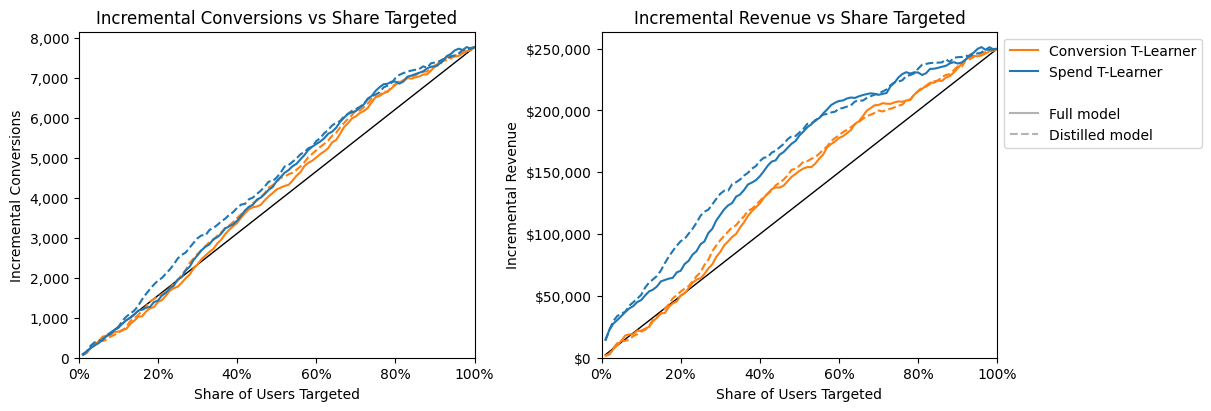

In [147]:
evaluator = fr.evaluate.UpliftEvaluator(
    metric_cols=["spend", "conversion"],
    is_treated_col="treatment",
    treatment_propensity_col="treatment_propensity",
    effect_type=fr.EffectType.ATE
)

models = {
    "spend_t_learner_score": "Spend T-Learner",
    "conversion_t_learner_score": "Conversion T-Learner",
    "spend_t_learner_score_distill": "Spend T-Learner",
    "conversion_t_learner_score_distill": "Conversion T-Learner",
}

results = evaluator.evaluate(criteo.test_data, score_cols=list(models.keys()))

fig, axs = plt.subplots(ncols=2, figsize=(12, 4), constrained_layout=True)

plot_cumulative_incrementality(
    axs[0],
    results,
    title="Incremental Conversions vs Share Targeted",
    model_names=models,
    x_col="share_targeted",
    y_col="conversion__inc_cum",
    x_label="Share of Users Targeted",
    y_label="Incremental Conversions",
    x_format="{:.0%}",
    y_format="{:,.0f}",
    show_legend=False,
    x_lim=[0, 1],
    y_lim=[0, None]
)

plot_cumulative_incrementality(
    axs[1],
    results,
    title="Incremental Revenue vs Share Targeted",
    model_names=models,
    x_col="share_targeted",
    y_col="spend__inc_cum",
    x_label="Share of Users Targeted",
    y_label="Incremental Revenue",
    x_format="{:.0%}",
    y_format="${:,.0f}",
    x_lim=[0, 1],
    y_lim=[0, None]
)

plt.show()

uplift model들이 제대로 작동하고 있는 것으로 보입니다. uplift curve가 대부분 random baseline(검은 선) 위에 위치해 있는데, 이는 사용자를 random으로 선택하는 것보다 더 나은 성과를 내고 있음을 의미합니다.

두 모델 모두 incremental conversions를 최적화하는 데에는 무난한 성능을 보이지만, incremental revenue를 찾아내는 데에서는 spend T-Learner가 확실히 더 우수한 성능을 보입니다.

이는 conversion T-Learner가 spend에 대한 정보를 전혀 알지 못하기 때문에 충분히 예상 가능한 결과입니다.

하지만 과연 이 방법이 uplift model을 평가하는 올바른 방법일까요? 일반적으로는 그렇지 않습니다. 사용자 비율을 기준으로 타겟팅하는 것이 동일한 비용 비율을 의미하지는 않기 때문입니다. 예컨대, 모델이 선택한 사용자들이 오히려 가장 cost가 많이 드는 사용자들일 수도 있습니다.

다음 섹션에서는 보다 현실적인 마케팅 목표를 기준으로 uplift model을 평가해 보고, 이러한 환경에서 T-Learner들이 적절한 fractional uplift model과 비교했을 때 얼마나 잘 동작하는지도 함께 살펴보겠습니다.

## Fractional uplift modelling

### Objective 1: Minimum Cost per Incremental Acquisition (CPiA)

첫 번째로 살펴볼 마케팅 목표는 incremental acquisition당 비용(cost per incremental acquisition, CPiA)을 최소화하는 것입니다. 여기서 acquisition은 conversion을 의미합니다.

즉, 우리가 얻는 incremental conversion 하나당 가능한 한 가장 적은 비용을 지출하는 것이 목표입니다. 

CPiA는 다음과 같이 정의됩니다.

$$ \text{CPiA} = \frac{\text{Cost}_{T=1}}{N_{\text{convert}, \, T=1} - N_{\text{convert}, \, T=0}} $$


#### Fractional uplift model

CPiA를 최적화하기 위해 fractional uplift model에서 다음과 같은 metric 설정을 사용합니다.

- Maximize KPI ($\alpha$) = Conversion  
- Constraint KPI ($\beta$) = Cost  
- Constraint Offset KPI ($\gamma$) = *사용하지 않음*

아래에서는 이러한 설정을 바탕으로 fractional uplift model을 학습합니다.

In [ ]:
train_data = fr.datasets.PandasTrainData(
    features_data=criteo.train_data[criteo.features],
    maximize_kpi=criteo.train_data["conversion"].values,
    constraint_kpi=criteo.train_data["cost"].values,
    is_treated=criteo.train_data["treatment"].values,
    treatment_propensity=criteo.train_data["treatment_propensity"].values,
    sample_weight=criteo.train_data["sample_weight"].values,
    shuffle_seed=1234
)
fractional_t_learner = fr.meta_learners.FractionalLearner(get_base_regressor())
fractional_t_learner.fit(train_data)

distill_fractional_t_learner = get_base_regressor()
fractional_t_learner.distill(distill_dataset, distill_fractional_t_learner)

criteo.test_data[f"cpia_score"] = fractional_t_learner.predict(test_dataset)
criteo.test_data[f"cpia_score_distill"] = distill_fractional_t_learner.predict(test_dataset)

In [149]:
criteo.test_data.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,cost_percentage,spend,cost,sample_weight,conversion_t_learner_score,conversion_t_learner_score_distill,spend_t_learner_score,spend_t_learner_score_distill,cpia_score,cpia_score_distill
1007,13.221509,10.059654,8.471764,-1.666396,13.059169,2.230907,-14.476362,9.170324,3.793946,39.917532,...,0.051091,37.386848,1.910123,1.0,0.035170,0.053963,0.217223,0.484556,0.025971,0.011292
1080,15.643772,10.059654,8.232822,3.907662,11.029584,4.115453,-1.288207,4.833815,3.858041,34.180688,...,0.469323,37.690649,17.689078,1.0,0.015709,0.015331,0.661332,0.196871,0.048494,0.030863
1295,13.236812,11.119309,8.329031,-2.570015,11.561050,1.128518,-18.659676,5.814641,3.855652,34.621266,...,0.007478,45.282760,0.338639,1.0,-0.233079,-0.195807,-12.409683,-8.438211,-0.363601,-0.103153
1670,19.622574,10.059654,8.305211,3.907662,13.253813,4.115453,-1.288207,4.833815,3.803324,41.176485,...,0.010958,44.872755,0.491714,1.0,-0.137972,-0.126640,-10.253737,-9.813921,-0.158326,-0.219133
1940,12.616365,10.059654,8.681976,4.679882,11.029584,4.115453,0.294443,4.833815,3.864711,13.190056,...,0.993622,19.274877,19.151940,1.0,0.002356,0.001106,0.003596,-0.081532,0.113706,0.011170


#### Evaluation

가장 낮은 CPiA는 가장 낮은 비용으로 가장 많은 incremental conversions를 달성하는 경우에 해당합니다. 이를 다음 두 가지 방식으로 평가합니다.

1. 총 비용(total cost)에 따른 incremental conversions를 시각화합니다. 동일한 비용에서 incremental conversions가 가장 높은 모델이 가장 우수한 모델입니다.
2. incremental conversions에 따른 CPiA를 시각화합니다. 동일한 incremental conversions에서 CPiA가 가장 낮은 모델이 가장 우수한 모델입니다.

이러한 지표들은 아래의 UpliftEvaluator를 사용하여 계산합니다.


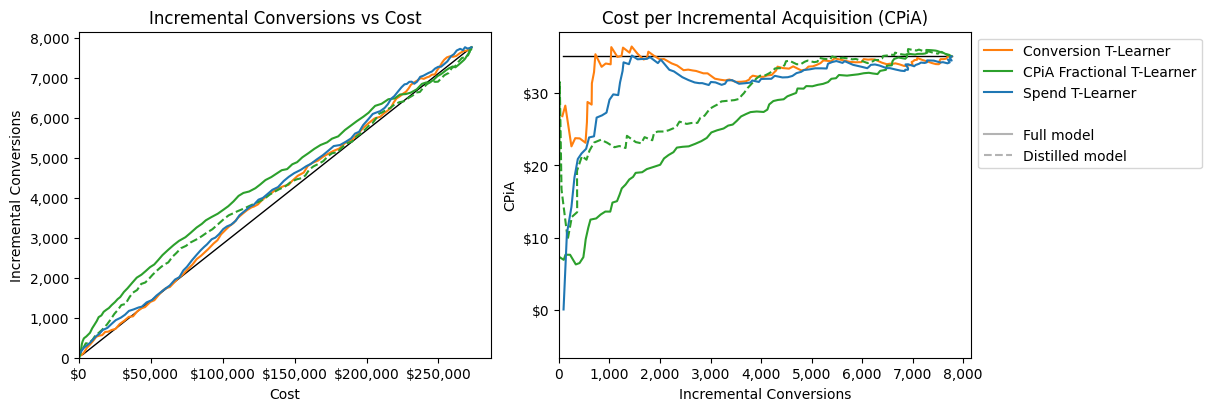

In [150]:
class CPIAUpliftEvaluator(fr.evaluate.UpliftEvaluator):
  def __init__(self, **kwargs):
    kwargs["metric_cols"] = ["spend", "conversion", "cost"]
    super().__init__(**kwargs)

  def _calculate_composite_metrics(self, data: pd.DataFrame) -> pd.DataFrame:
    data["cpia__inc_cum"] = data["cost__inc_cum"] / data["conversion__inc_cum"]
    data["cpia__inc"] = data["cost__inc"] / data["conversion__inc"]
    return data

evaluator = CPIAUpliftEvaluator(
    is_treated_col="treatment",
    treatment_propensity_col="treatment_propensity",
    effect_type=fr.EffectType.ATE
)

models = {
    "spend_t_learner_score": "Spend T-Learner",
    "conversion_t_learner_score": "Conversion T-Learner",
    "cpia_score": "CPiA Fractional T-Learner",
    "cpia_score_distill": "CPiA Fractional T-Learner",
}

results = evaluator.evaluate(criteo.test_data, score_cols=list(models.keys()))

fig, axs = plt.subplots(ncols=2, figsize=(12, 4), constrained_layout=True)

plot_cumulative_incrementality(
    axs[0],
    results,
    title="Incremental Conversions vs Cost",
    model_names=models,
    x_col="cost__inc_cum",
    y_col="conversion__inc_cum",
    x_label="Cost",
    y_label="Incremental Conversions",
    x_format="${:,.0f}",
    y_format="{:,.0f}",
    x_lim=[0, None],
    y_lim=[0, None],
    show_legend=False
)

plot_cumulative_incrementality(
    axs[1],
    results,
    title="Cost per Incremental Acquisition (CPiA)",
    model_names=models,
    x_col="conversion__inc_cum",
    y_col="cpia__inc_cum",
    x_label="Incremental Conversions",
    y_label="CPiA",
    x_format="{:,.0f}",
    y_format="${:,.0f}",
    x_lim=[0, None]
)

plt.show()

fractional uplift 모델은 기존 uplift 모델보다 명확하게 더 우수한 성과를 보입니다. 동일한 비용 대비 훨씬 낮은 CPiA를 달성하고, 더 많은 추가 전환(incremental conversions)을 만들어냅니다. 

반면 T-Learner는 일부 경우 오히려 CPiA를 증가시키는 모습을 보입니다. 이는 T-Learner가 비용을 고려하지 않기 때문에, 증분 효과는 크지만 비용이 높은 사용자들을 타겟팅하게 되고, 그 결과 전체적으로는 더 나쁜 CPiA를 초래하기 때문입니다.


### Objective 2: Maximum iRoI

이번에는 CPiA가 아니라 수익(revenue) 관점에서 살펴보겠습니다. 모든 전환이 동일한 가치를 갖는 것은 아니며, 어떤 전환은 다른 전환보다 훨씬 더 큰 매출을 만들어냅니다.

따라서 가능한 한 낮은 비용으로 최대의 추가 매출(incremental revenue, spend) 을 창출하고자 한다면, 우리의 목표는 iRoI를 최대화하는 것이 됩니다.

$$
\text{iRoI} = \frac{\text{Spend}_\text{T=1} - \text{Spend}_\text{T=0}}{\text{Cost}_\text{T=1}}
$$


#### Fractional uplift model

iRoI를 최적화하기 위해 fractional uplift 모델에서 다음과 같이 지표를 설정합니다.

- Maximize KPI ($\alpha$) = Spend  
- Constraint KPI ($\beta$) = Cost  
- Constraint Offset KPI ($\gamma$) = *사용하지 않음*

아래에서는 이러한 설정을 바탕으로 fractional uplift 모델을 학습합니다.

In [ ]:
train_data = fr.datasets.PandasTrainData(
    features_data=criteo.train_data[criteo.features],
    maximize_kpi=criteo.train_data["spend"].values,
    constraint_kpi=criteo.train_data["cost"].values,
    is_treated=criteo.train_data["treatment"].values,
    treatment_propensity=criteo.train_data["treatment_propensity"].values,
    sample_weight=criteo.train_data["sample_weight"].values,
    shuffle_seed=1234
)
fractional_t_learner = fr.meta_learners.FractionalLearner(get_base_regressor())
fractional_t_learner.fit(train_data)

distill_fractional_t_learner = get_base_regressor()
fractional_t_learner.distill(distill_dataset, distill_fractional_t_learner)

criteo.test_data[f"roi_score"] = fractional_t_learner.predict(test_dataset)
criteo.test_data[f"roi_score_distill"] = distill_fractional_t_learner.predict(test_dataset)

#### Evaluation

가장 높은 iRoI는 가장 낮은 비용으로 가장 많은 추가 매출(incremental revenue) 을 달성한 경우에 해당합니다. 이를 다음 두 가지 방식으로 평가합니다.

1. 총 비용 대비 추가 매출을 시각화합니다. 동일한 비용에서 추가 매출이 가장 높은 모델이 가장 우수한 모델입니다.
2. 추가 매출 대비 iRoI를 시각화합니다. 동일한 추가 매출 수준에서 iRoI가 가장 높은 모델이 가장 우수한 모델입니다.

이러한 지표들은 아래의 UpliftEvaluator를 사용해 계산합니다.

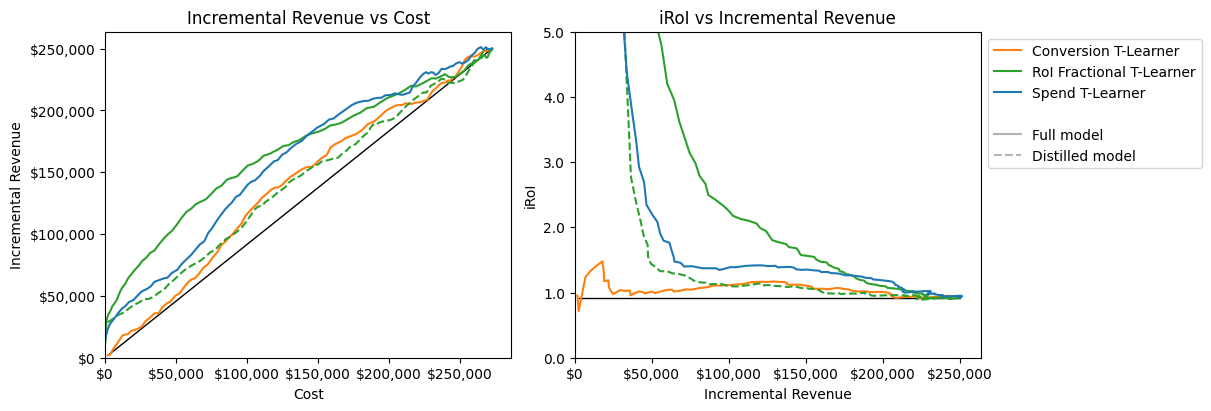

In [152]:
class RoIUpliftEvaluator(fr.evaluate.UpliftEvaluator):
  def __init__(self, **kwargs):
    kwargs["metric_cols"] = ["spend", "conversion", "cost"]
    super().__init__(**kwargs)

  def _calculate_composite_metrics(self, data: pd.DataFrame) -> pd.DataFrame:
    data["roi__inc_cum"] = data["spend__inc_cum"] / data["cost__inc_cum"]
    data["roi__inc"] = data["spend__inc"] / data["cost__inc"]
    return data

evaluator = RoIUpliftEvaluator(
    is_treated_col="treatment",
    treatment_propensity_col="treatment_propensity",
    effect_type=fr.EffectType.ATE
)

models = {
    "spend_t_learner_score": "Spend T-Learner",
    "conversion_t_learner_score": "Conversion T-Learner",
    "roi_score": "RoI Fractional T-Learner",
    "roi_score_distill": "RoI Fractional T-Learner",
}

results = evaluator.evaluate(criteo.test_data, score_cols=list(models.keys()))

fig, axs = plt.subplots(ncols=2, figsize=(12, 4), constrained_layout=True)

plot_cumulative_incrementality(
    axs[0],
    results,
    title="Incremental Revenue vs Cost",
    model_names=models,
    x_col="cost__inc_cum",
    y_col="spend__inc_cum",
    x_label="Cost",
    y_label="Incremental Revenue",
    x_format="${:,.0f}",
    y_format="${:,.0f}",
    show_legend=False,
    x_lim=[0, None],
    y_lim=[0, None],
)

plot_cumulative_incrementality(
    axs[1],
    results,
    title="iRoI vs Incremental Revenue",
    model_names=models,
    x_col="spend__inc_cum",
    y_col="roi__inc_cum",
    x_label="Incremental Revenue",
    y_label="iRoI",
    x_format="${:,.0f}",
    y_format="{:.1f}",
    x_lim=[0, None],
    y_lim=[0, 5]
)

plt.show()

이번 경우에서도 fractional uplift 모델이 기존 uplift 모델보다 더 우수한 성과를 보입니다. 일반적인 spend T-Learner 꽤 괜찮은 성능을 내지만, RoI를 최적화한 fractional learner에는 미치지 못합니다. 

또한 이 경우에는 distilled 버전이 전체(full) 모델의 성능을 충분히 잘 따라가지 못하는 것으로 보이며, 추가적인 튜닝이 필요함을 시사합니다.

### Objective 3: Maximum Incremental Conversions with an RoI Constraint

마지막으로 살펴볼 경우는 iRoI가 특정 목표 값 이하로 떨어지지 않도록 유지하면서, 가능한 한 많은 추가 전환(incremental conversions) 을 만들어내는 상황입니다.

이 예제에서는 iRoI 목표값을 2.0으로 설정합니다.

#### Fractional uplift model

이 문제는 constraint가 포함되어 있어 조금 더 복잡하지만, fractional uplift 설정을 통해 해결할 수 있습니다. 이를 위해 다음과 같이 설정합니다.

* Maximize KPI ($\alpha$) = Conversion  
* Constraint KPI ($\beta$) = Cost  
* Constraint Offset KPI ($\gamma$) = Spend  
* Constraint Offset Scale ($\delta$) = iRoI target  

이 설정은 uplift 모델이 다음과 같은 값을 추정하도록 만듭니다.

$$
f_\delta(X)=
\begin{cases}
    \frac{N_{\text{convert}, \, T=1} - N_{\text{convert}, \, T=0}}{\text{Cost}_{T=1} - \frac{\text{Spend}_\text{T=1} - \text{Spend}_\text{T=0}}{\text{iRoI}_\text{target}}},& \text{Cost}_{T=1} > \frac{\text{Spend}_\text{T=1} - \text{Spend}_\text{T=0}}{\text{iRoI}_\text{target}}\\
    \infty,              & \text{otherwise}
\end{cases}
$$

이를 직관적으로 보면 다음과 같이 해석할 수 있습니다.

1. 사용자의 iRoI가 iRoI target보다 높다면, 항상 해당 사용자를 타겟팅합니다.
2. iRoI가 target보다 낮은 경우에는,  
   incremental conversions을 얼마나 만들어내는지를  
   net cost으로 나눈 값으로 사용자를 정렬합니다.  
   여기서 순비용은 iRoI target을 초과해서 발생하는 비용을 의미합니다.  
   즉, iRoI target을 가장 적게 훼손하면서 가장 많은 incremental conversions를 만드는 사용자부터 타겟팅합니다.

아래에서는 이를 실제로 구현합니다.

In [ ]:
target_roi = 2.0

train_data = fr.datasets.PandasTrainData(
    features_data=criteo.train_data[criteo.features],
    maximize_kpi=criteo.train_data["conversion"].values,
    constraint_kpi=criteo.train_data["cost"].values,
    constraint_offset_kpi=criteo.train_data["spend"].values,
    is_treated=criteo.train_data["treatment"].values,
    treatment_propensity=criteo.train_data["treatment_propensity"].values,
    sample_weight=criteo.train_data["sample_weight"].values,
    shuffle_seed=1234
)
fractional_t_learner = fr.meta_learners.FractionalLearner(get_base_regressor())
fractional_t_learner.fit(train_data)

distill_fractional_t_learner = get_base_regressor()
fractional_t_learner.distill(distill_dataset, distill_fractional_t_learner, constraint_offset_scale=target_roi)

criteo.test_data[f"roi_constrained_conversion_score"] = fractional_t_learner.predict(
    test_dataset, constraint_offset_scale=target_roi
)
criteo.test_data[f"roi_constrained_conversion_score_distill"] = distill_fractional_t_learner.predict(test_dataset)

In [154]:
criteo.test_data.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,conversion_t_learner_score,conversion_t_learner_score_distill,spend_t_learner_score,spend_t_learner_score_distill,cpia_score,cpia_score_distill,roi_score,roi_score_distill,roi_constrained_conversion_score,roi_constrained_conversion_score_distill
1007,13.221509,10.059654,8.471764,-1.666396,13.059169,2.230907,-14.476362,9.170324,3.793946,39.917532,...,0.035170,0.053963,0.217223,0.484556,0.025971,0.011292,0.160407,-1.164981,0.028235,30.174107
1080,15.643772,10.059654,8.232822,3.907662,11.029584,4.115453,-1.288207,4.833815,3.858041,34.180688,...,0.015709,0.015331,0.661332,0.196871,0.048494,0.030863,2.041546,1.063659,inf,30.259451
1295,13.236812,11.119309,8.329031,-2.570015,11.561050,1.128518,-18.659676,5.814641,3.855652,34.621266,...,-0.233079,-0.195807,-12.409683,-8.438211,-0.363601,-0.103153,-19.358949,-1.164981,-0.034047,10.612205
1670,19.622574,10.059654,8.305211,3.907662,13.253813,4.115453,-1.288207,4.833815,3.803324,41.176485,...,-0.137972,-0.126640,-10.253737,-9.813921,-0.158326,-0.219133,-11.766439,-1.164981,-0.023002,0.024123
1940,12.616365,10.059654,8.681976,4.679882,11.029584,4.115453,0.294443,4.833815,3.864711,13.190056,...,0.002356,0.001106,0.003596,-0.081532,0.113706,0.011170,0.173577,0.932336,0.124512,3.947203


#### Evaluation

이를 평가하기 위해, iRoI가 목표 iRoI 값인 2.0과 같아지는 지점에서 달성할 수 있는 최대 전환 수를 확인합니다. 

아래에서는 다시 한 번 uplift evaluator를 사용해, incremental conversions에 따른 iRoI의 변화를 그래프로 시각화합니다.

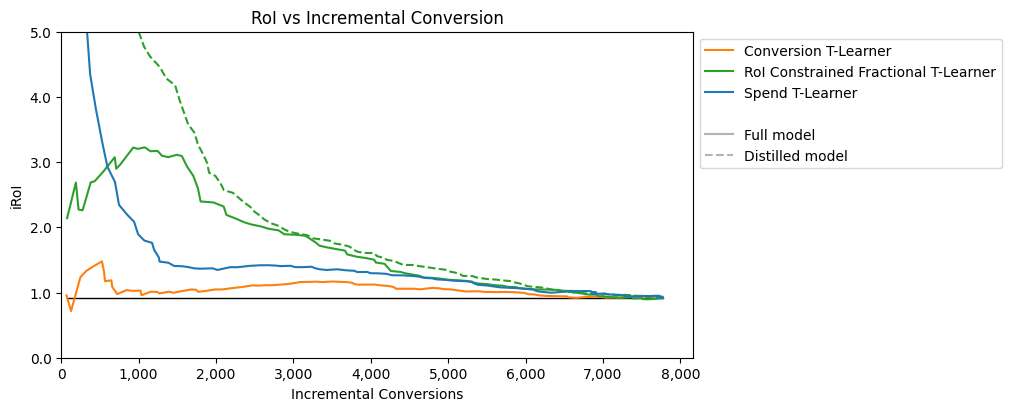

In [155]:
evaluator = RoIUpliftEvaluator(
    is_treated_col="treatment",
    treatment_propensity_col="treatment_propensity",
    effect_type=fr.EffectType.ATE
)

models = {
    "spend_t_learner_score": "Spend T-Learner",
    "conversion_t_learner_score": "Conversion T-Learner",
    "roi_constrained_conversion_score": "RoI Constrained Fractional T-Learner",
    "roi_constrained_conversion_score_distill": "RoI Constrained Fractional T-Learner",
}

results = evaluator.evaluate(criteo.test_data, score_cols=list(models.keys()))

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)

roi_plot = plot_cumulative_incrementality(
    ax,
    results,
    title="RoI vs Incremental Conversion",
    model_names=models,
    x_col="conversion__inc_cum",
    y_col="roi__inc_cum",
    x_label="Incremental Conversions",
    y_label="iRoI",
    x_format="{:,.0f}",
    y_format="{:.1f}",
    x_lim=[0, None],
    y_lim=[0, 5]
)

plt.show()

fractional learner가 단순한 T-learner들보다 우수한 성과를 보인다는 점이 분명하게 드러납니다.
fractional learner는 iRoI가 2.0인 조건에서 약 3,000건의 incremental conversions을 달성합니다.

반면, conversion T-learner는 iRoI 2.0에 도달하지 못하며,
Spend T-learner 역시 iRoI가 2.0일 때 약 1,000건의 incremental conversions만을 만들어낼 수 있습니다.